<a href="https://colab.research.google.com/github/Yaroslavwvw/neural_networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D1%8B_%D0%9D%D0%A1_%D0%B8_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 1. Использование предобученной модели

### 1.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

# Загружаем предобученную модель
model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### 1.2. Загрузите из сети Интернет 5 изображений с разными классами, из тех, что приведены в [списке](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), и сохраните их представление в список images

In [ ]:
image_paths = [
    'bee.jpg',
    'cheeseburger.jpg',
    'hammer.jpg',
    'teapot.jpg',
    'zebra.jpg'
]

# Загружаем изображения в PIL формате
images = [Image.open(path) for path in image_paths]

### 1.3. Напишите функцию, принимающую на вход список с исходными изображениями и возвращающую список с преобразованными изображениями под формат входных данных выбранной Вами модели СНС (нормализация).

(Не забудьте создать независимую копию исходного списка в теле функции, для обработки именно независимой копии, а не оригинального списка)

In [ ]:
def preprocess_images(images_list):
    processed_images = []
    # Создаем независимую копию
    images_copy = [img.copy() for img in images_list]

    for img in images_copy:
        # Изменяем размер и преобразуем в массив
        img = img.resize((224, 224))  # ResNet требует 224x224
        img_array = image.img_to_array(img)
        # Добавляем размерность батча и применяем предобработку
        img_array = preprocess_input(img_array)
        processed_images.append(img_array)

    return np.array(processed_images)

### 1.5. Выведите изображения и соответствующие им классы (как в примере из теории)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


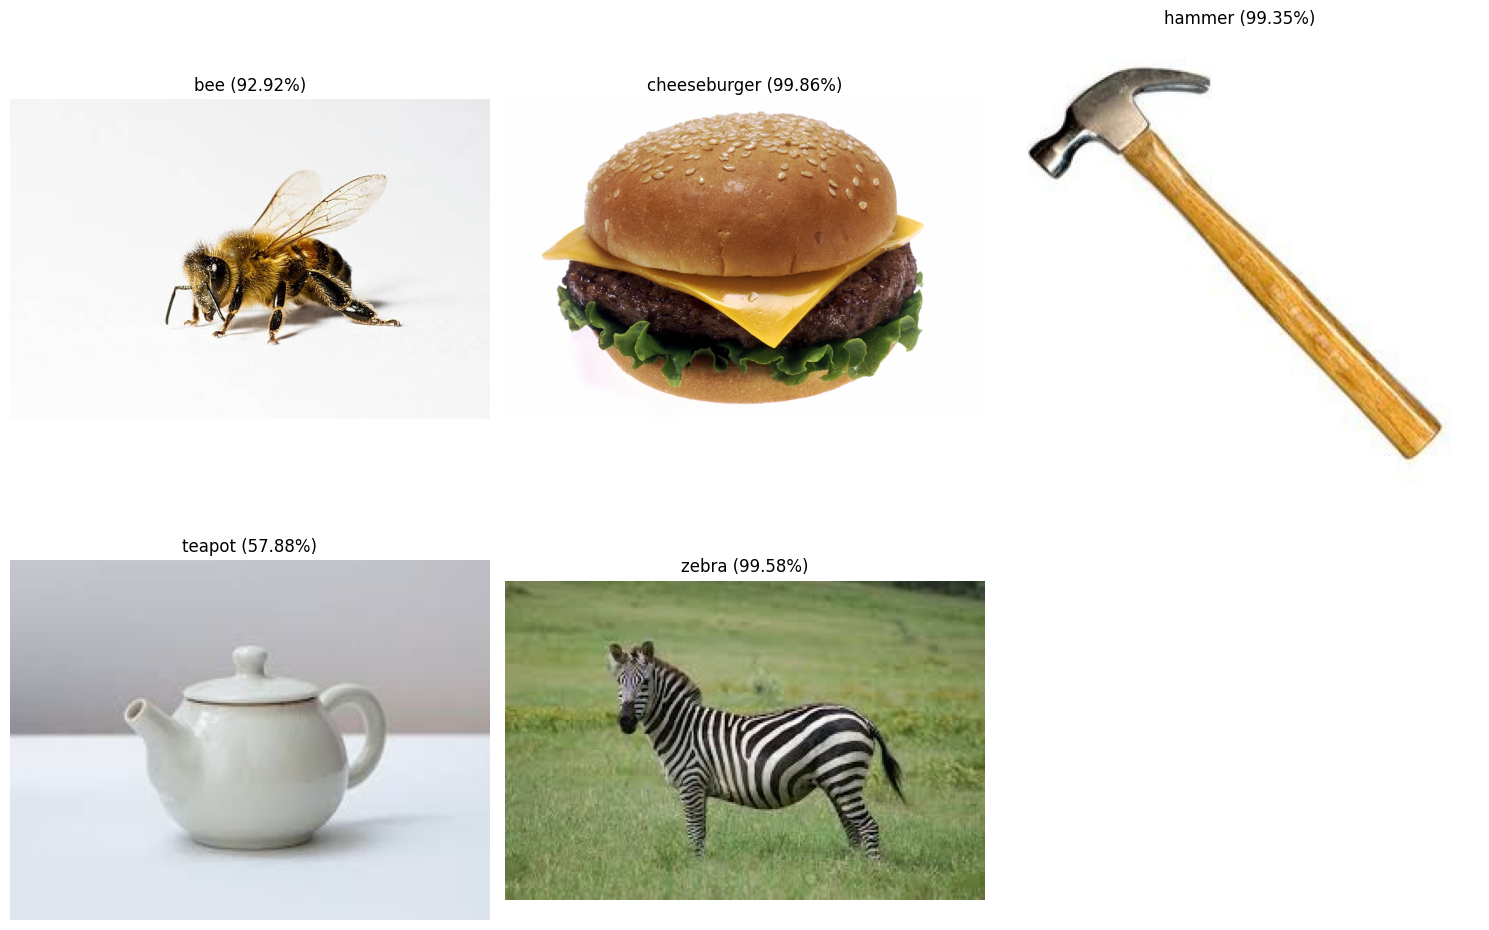

In [ ]:
processed_images = preprocess_images(images)

# Делаем предсказания
preds = model.predict(processed_images)
decoded_preds = decode_predictions(preds, top=1)

# Выводим изображения с подписями
plt.figure(figsize=(15, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(f'{decoded_preds[i][0][1]} ({decoded_preds[i][0][2]*100:.2f}%)')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Задание 2. Использование обученной модели для работы со своим датасетом

### 2.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.6 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import gradio as gr
import numpy as np
import os

### 2.2. Подготовка тренировочных данных. Разделение на обучающую и тестовую выборку

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kausthubkannan/5-flower-types-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 242M/242M [00:01<00:00, 178MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kausthubkannan/5-flower-types-classification-dataset/versions/1


In [ ]:
dataset_path = f"{path}/flower_images"
class_names = ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory


BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Создаем тренировочный и тестовый наборы
train_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

validation_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

Found 4999 files belonging to 5 classes.
Using 4000 files for training.
Found 4999 files belonging to 5 classes.
Using 999 files for validation.


### 2.3. Обучение своей модели на основе предобученной модели "*название модели, выбранной в п.2.1.*"

In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization, Dropout, Activation
from tensorflow.keras.callbacks import EarlyStopping

# Создание улучшенной модели
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Замораживаем базовые слои
base_model.trainable = False

inputs = base_model.input
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Добавляем BatchNorm и Dropout
x = Dense(512, kernel_regularizer=regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, kernel_regularizer=regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True)

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[early_stop])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 162ms/step - accuracy: 0.3692 - loss: 12.9214 - val_accuracy: 0.7848 - val_loss: 11.0775
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.7130 - loss: 10.8988 - val_accuracy: 0.8498 - val_loss: 9.7198
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 0.8006 - loss: 9.5410 - val_accuracy: 0.8729 - val_loss: 8.5577
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.8180 - loss: 8.4230 - val_accuracy: 0.8899 - val_loss: 7.5412
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.8559 - loss: 7.3793 - val_accuracy: 0.8979 - val_loss: 6.6588
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - accuracy: 0.8749 - loss: 6.5176 - val_accuracy: 0.9079 - val_loss: 5.8944
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - accuracy: 0.8913 - loss: 5.7628 - val_accuracy: 0.9069 - val_loss: 5.2377
Epoch 8/30
125/125 ━━━━━━━━━━━

### 2.4. Визуализация процесса обучения модели

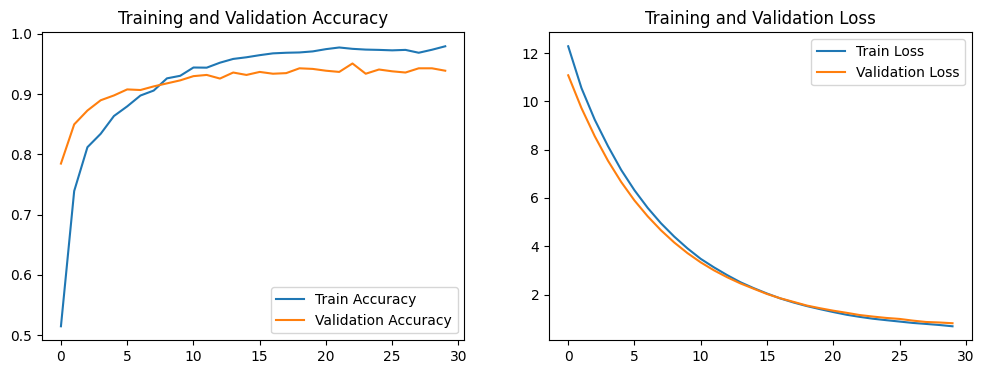

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [ ]:
model.save('flower_classification_model5.h5')

### 2.5. Подготовьте набор проверочных данных (examples)

In [ ]:
examples = [
    'lilly.jpg',
    'lotus.jpg',
    'orchid.jpg',
    'sunflower.jpg',
    'tulip.jpg'
]

# Проверяем существование файлов
for path in examples:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Файл {path} не найден!")

### 2.6. Реализуйте графический интерфейс для взаимодействия с обученной моделью, используя [Gradio](https://www.gradio.app/guides/image-classification-in-tensorflow). В качестве примеров (параметр examples в Gradio), используйте изображения из списка images (п.1.2.)

In [ ]:
def classify_image(img):
    # Преобразование изображения
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Предсказание
    preds = model.predict(img_array)
    return {class_names[i]: float(preds[0][i]) for i in range(len(class_names))}

# Создаем интерфейс с кастомными примерами
iface = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="pil", label="Загрузите изображение цветка"),
    outputs=gr.Label(num_top_classes=3, label="Результаты классификации"),
    examples=examples,
    title="🌷 Классификатор цветов",
    description="Классифицируйте изображения цветов по 5 категориям: " + ", ".join(class_names),
    allow_flagging="never"
)

# Запуск интерфейса
iface.launch(share=True)

/usr/local/lib/python3.11/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated.Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://87adf1bdd4622d4b15.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


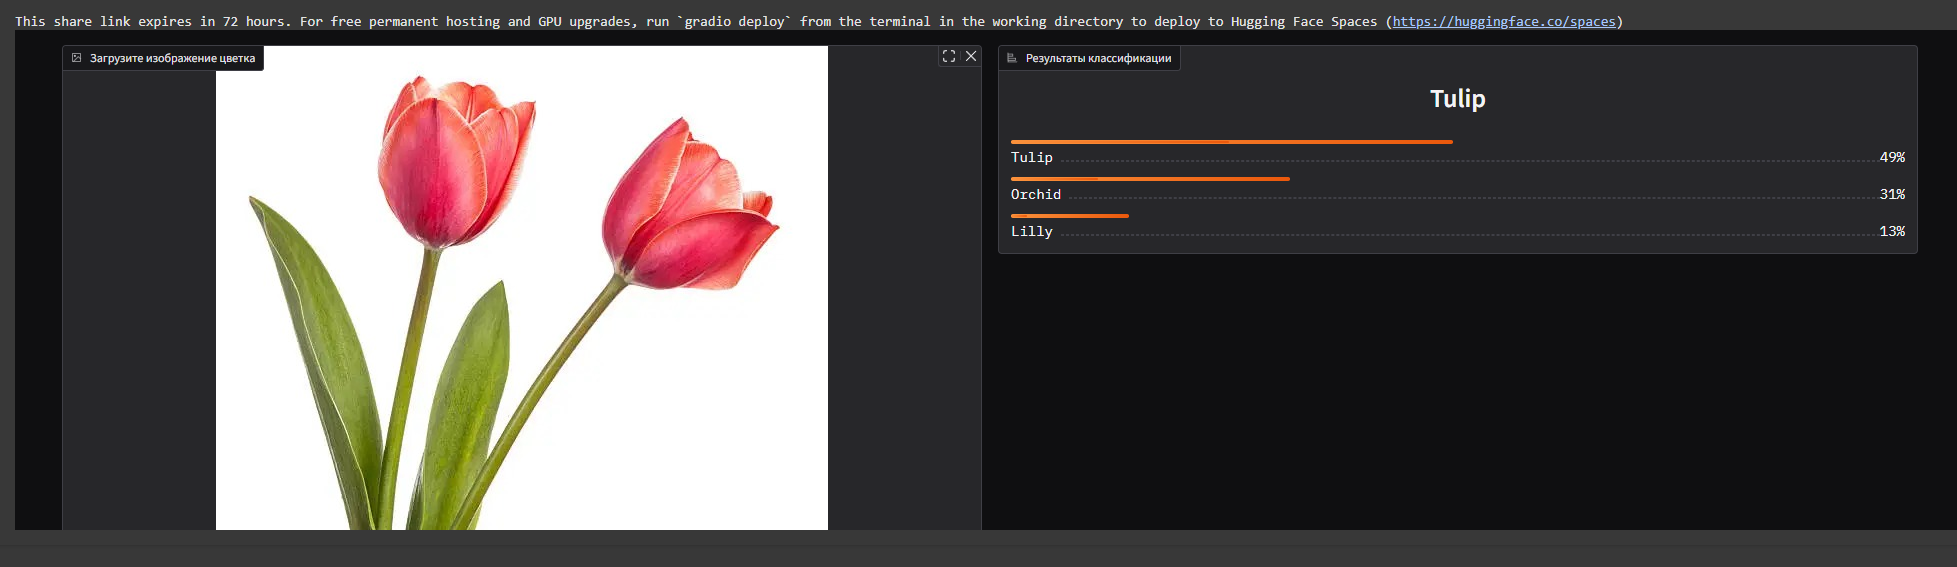

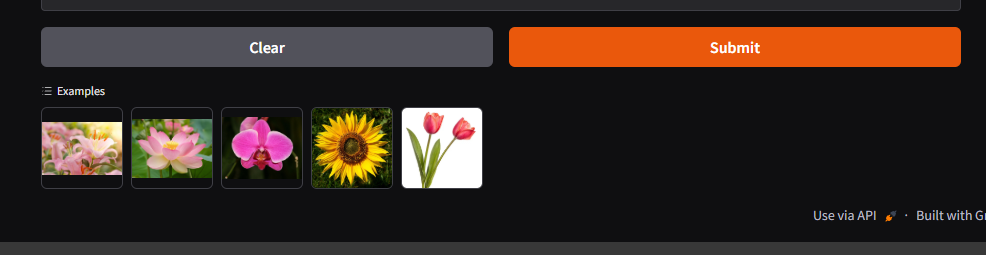